# Automatic Number Plate Recognition (ANPR)
## YOLOv8 and CRNN Integration

### Introduction

This notebook presents the complete Automatic Number Plate Recognition (ANPR) system by integrating the trained YOLOv8 object detection model with the trained Convolutional Recurrent Neural Network (CRNN) optical character recognition (OCR) model.

The YOLOv8 model is responsible for detecting and localizing the license plate within an input vehicle image. Once detected, the license plate region is cropped and preprocessed before being passed to the CRNN model. The CRNN then recognizes the sequence of alphanumeric characters on the license plate. Finally, Connectionist Temporal Classification (CTC) decoding is applied to obtain the final license plate prediction.

This notebook demonstrates the complete inference pipeline from image input to license plate recognition using the trained models developed in the previous phases of this project.

---

## Workflow

1. Load the trained YOLOv8 model.
2. Load the trained CRNN model.
3. Detect the license plate from the input image.
4. Crop and preprocess the detected license plate.
5. Recognize the license plate characters using CRNN.
6. Decode the prediction using CTC decoding.
7. Display the final recognition result.

# 1. Import Libraries

This section imports all required Python libraries used throughout the ANPR integration process.

The imported libraries provide functionality for:

- Image processing using OpenCV and Pillow (PIL).
- Numerical operations using NumPy.
- Deep learning inference using PyTorch.
- Object detection using the Ultralytics YOLOv8 framework.
- Data visualization using Matplotlib.
- Image preprocessing using TorchVision transforms.

These libraries are required to load the trained models, preprocess the detected license plate, perform character recognition, and visualize the final prediction.

In [146]:
# =====================================================
# Import Libraries
# =====================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from ultralytics import YOLO
from torchvision import transforms

# 2. Configuration

This section defines the configuration settings used throughout the ANPR integration process.

The configuration includes the computing device (GPU or CPU), the file paths for the trained YOLOv8 and CRNN models, and the location of the input image used for testing. These settings are defined in a single location to improve code readability and simplify future modifications.

The notebook automatically detects whether CUDA is available. If a compatible NVIDIA GPU is detected, inference will be performed using the GPU to improve processing speed. Otherwise, the system will automatically fall back to the CPU.

In [147]:
# =====================================================
# Configuration
# =====================================================

import torch

# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model Paths
YOLO_MODEL_PATH = r"C:\Users\Dani\Desktop\FYPCODE\runs\detect\ANPR\YOLOv8m\weights\best.pt"
CRNN_MODEL_PATH = r"C:\Users\Dani\Desktop\FYPCODE\best_crnn.pth"

# Test Image
TEST_IMAGE_PATH = r"C:\Users\Dani\Desktop\FYPCODE\TestImages\test2.jpg"

print("=" * 60)
print("ANPR Configuration")
print("=" * 60)
print(f"Device           : {DEVICE}")
print(f"YOLO Model Path  : {YOLO_MODEL_PATH}")
print(f"CRNN Model Path  : {CRNN_MODEL_PATH}")
print(f"Test Image       : {TEST_IMAGE_PATH}")
print("=" * 60)

ANPR Configuration
Device           : cuda
YOLO Model Path  : C:\Users\Dani\Desktop\FYPCODE\runs\detect\ANPR\YOLOv8m\weights\best.pt
CRNN Model Path  : C:\Users\Dani\Desktop\FYPCODE\best_crnn.pth
Test Image       : C:\Users\Dani\Desktop\FYPCODE\TestImages\test2.jpg


# 3. Load YOLOv8 Model

The trained YOLOv8 model is loaded into memory to perform license plate detection.

YOLOv8 is responsible for identifying the location of the license plate within the input vehicle image by predicting a bounding box around the detected plate. During inference, the model processes the entire image and returns the coordinates of the detected license plate, which will later be cropped and passed to the CRNN model for character recognition.

The model weights used in this notebook are the best-performing weights obtained during the YOLOv8 training phase.

In [148]:
# =====================================================
# Load YOLOv8 Model
# =====================================================

from ultralytics import YOLO

# Load trained YOLO model
yolo_model = YOLO(YOLO_MODEL_PATH)

print("=" * 60)
print("YOLOv8 Model Loaded Successfully!")
print("=" * 60)

YOLOv8 Model Loaded Successfully!


# 4. Load CRNN Model

This section loads the trained Convolutional Recurrent Neural Network (CRNN) model used for Optical Character Recognition (OCR).

The CRNN model was trained in the previous notebook to recognize Malaysian vehicle license plate characters from cropped license plate images. The model combines three main components:

- **Convolutional Neural Network (CNN)** to extract visual features from the license plate image.
- **Bidirectional Long Short-Term Memory (BiLSTM)** network to capture sequential relationships between characters.
- **Fully Connected (FC)** layer to classify each character position.

The trained model weights (`best_crnn.pth`) are then loaded into memory, allowing the model to perform character recognition during inference.

In [149]:
# =====================================================
# Import PyTorch Neural Network Modules
# =====================================================

import torch
import torch.nn as nn

## 4.1 Character Vocabulary

The CRNN model predicts characters based on the vocabulary used during training. The vocabulary consists of numerical digits (0–9) and uppercase English alphabets (A–Z).

Since the CRNN model is trained using Connectionist Temporal Classification (CTC) Loss, an additional blank token is reserved at index 0. Therefore, the total number of output classes equals the number of characters plus one blank class.

In [150]:
# =====================================================
# Character Vocabulary
# =====================================================

CHARSET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"

CTC_BLANK = 0

char_to_idx = {c: i + 1 for i, c in enumerate(CHARSET)}
idx_to_char = {i + 1: c for i, c in enumerate(CHARSET)}

num_classes = len(CHARSET) + 1

print("=" * 60)
print("Character Vocabulary Loaded")
print(f"Characters : {len(CHARSET)}")
print(f"Classes    : {num_classes}")
print("=" * 60)

Character Vocabulary Loaded
Characters : 36
Classes    : 37


## 4.2 Define CRNN Architecture

The CRNN architecture used for inference must be identical to the architecture used during training. This ensures that the saved model weights can be loaded correctly without any mismatch.

The architecture consists of:

- Six convolutional blocks for feature extraction.
- Two Bidirectional LSTM layers for sequence modelling.
- One fully connected output layer for character prediction.

In [151]:
# =====================================================
# CRNN Model
# =====================================================

class CRNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # =================================================
        # CNN Feature Extractor
        # =================================================

        self.cnn = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # Block 4
            nn.Conv2d(
                in_channels=256,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,1), stride=(2,1)),

            # Block 5
            nn.Conv2d(
                in_channels=256,
                out_channels=512,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            # Block 6
            nn.Conv2d(
                in_channels=512,
                out_channels=512,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,1), stride=(2,1)),

            # Final Convolution
            nn.Conv2d(
                in_channels=512,
                out_channels=512,
                kernel_size=2,
                stride=1,
                padding=0
            ),
            nn.ReLU(inplace=True)
        )

        # =================================================
        # Bidirectional LSTM
        # =================================================

        self.rnn = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        # =================================================
        # Fully Connected Layer
        # =================================================

        self.fc = nn.Linear(
            in_features=512,
            out_features=num_classes
        )

    # =====================================================
    # Forward Pass
    # =====================================================

    def forward(self, x):

        # -----------------------------
        # CNN Feature Extraction
        # -----------------------------
        x = self.cnn(x)

        # Shape:
        # (Batch, Channels, Height, Width)

        batch_size, channels, height, width = x.size()

        # Height should be 1
        assert height == 1, f"Expected feature map height = 1, but got {height}"

        # Remove Height Dimension
        # (B, C, 1, W) -> (B, C, W)
        x = x.squeeze(2)

        # Rearrange for LSTM
        # (B, C, W) -> (B, W, C)
        x = x.permute(0, 2, 1)

        # -----------------------------
        # BiLSTM
        # -----------------------------
        x, _ = self.rnn(x)

        # -----------------------------
        # Character Classification
        # -----------------------------
        x = self.fc(x)

        return x


## 4.3 Load Trained CRNN Weights

After defining the CRNN architecture, the trained model weights are loaded from the saved checkpoint (`best_crnn.pth`).

The model is then transferred to the selected computing device (GPU or CPU) and switched to evaluation mode. During evaluation mode, training-specific operations such as dropout and batch normalization updates are disabled, ensuring consistent predictions during inference.

In [152]:
# =====================================================
# Load Trained CRNN Weights
# =====================================================

# Create model
model = CRNN(num_classes).to(DEVICE)

# Load trained weights
model.load_state_dict(
    torch.load(CRNN_MODEL_PATH, map_location=DEVICE)
)

# Evaluation mode
model.eval()

print("=" * 60)
print("CRNN Model Loaded Successfully!")
print("=" * 60)

CRNN Model Loaded Successfully!


# 5. Image Preprocessing

After detecting the license plate using YOLOv8, the cropped license plate image must be preprocessed before being passed to the CRNN model.

To ensure consistency with the training phase, the preprocessing pipeline used during inference is identical to the one used for training. The cropped license plate image is converted to grayscale, resized while preserving its aspect ratio, placed on a fixed-size canvas, normalized, and converted into a PyTorch tensor.

Maintaining the same preprocessing procedure helps the CRNN model generalize correctly and improves recognition accuracy.

In [153]:
# =====================================================
# Image Preprocessing
# =====================================================

# Image Size Used During Training
IMAGE_HEIGHT = 32
IMAGE_WIDTH = 128

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


def preprocess_plate(plate_image):
    """
    Preprocess a cropped license plate image for CRNN inference.

    Parameters
    ----------
    plate_image : numpy.ndarray
        Cropped license plate image from YOLO (OpenCV format).

    Returns
    -------
    torch.Tensor
        Preprocessed image tensor with shape:
        (1, 1, 32, 128)
    """

    # =================================================
    # Convert OpenCV BGR Image to Grayscale
    # =================================================
    gray = cv2.cvtColor(plate_image, cv2.COLOR_BGR2GRAY)

    # =================================================
    # Convert NumPy Array to PIL Image
    # =================================================
    image = Image.fromarray(gray)

    # =================================================
    # Get Original Image Size
    # =================================================
    width, height = image.size

    # =================================================
    # Preserve Aspect Ratio
    # =================================================
    scale = min(
        IMAGE_WIDTH / width,
        IMAGE_HEIGHT / height
    )

    new_width = int(width * scale)
    new_height = int(height * scale)

    # =================================================
    # Resize Image
    # =================================================
    image = image.resize(
        (new_width, new_height),
        Image.BILINEAR
    )

    # =================================================
    # Create Black Canvas
    # =================================================
    canvas = Image.new(
        "L",
        (IMAGE_WIDTH, IMAGE_HEIGHT),
        color=0
    )

    # =================================================
    # Center Image on Canvas
    # =================================================
    x_offset = (IMAGE_WIDTH - new_width) // 2
    y_offset = (IMAGE_HEIGHT - new_height) // 2

    canvas.paste(
        image,
        (x_offset, y_offset)
    )

    # =================================================
    # Convert to Tensor
    # =================================================
    image = transform(canvas)

    # =================================================
    # Add Batch Dimension
    # =================================================
    image = image.unsqueeze(0)

    # =================================================
    # Move to Device
    # =================================================
    return image.to(DEVICE)

# 6. CTC Decoding

The CRNN model predicts a sequence of character probabilities instead of directly outputting the final license plate text. Therefore, a decoding process is required to convert these predictions into readable characters.

The Connectionist Temporal Classification (CTC) decoding algorithm performs the following operations:

1. Selects the character with the highest probability at each time step.
2. Removes consecutive duplicate predictions.
3. Removes blank tokens introduced by the CTC Loss function.
4. Converts the remaining character indices into the corresponding license plate characters.

The decoded output represents the final recognized license plate.

In [154]:
# =====================================================
# CTC Decoder
# =====================================================

def ctc_decode(output):
    """
    Decode CRNN output using CTC greedy decoding.

    Parameters
    ----------
    output : torch.Tensor
        CRNN output with shape:
        (batch_size, sequence_length, num_classes)

    Returns
    -------
    str
        Decoded license plate text.
    """

    # Get the most probable class at each timestep
    prediction = output.argmax(2)

    # Convert to NumPy array
    prediction = prediction.squeeze(0).cpu().numpy()

    decoded = []
    previous = CTC_BLANK

    for p in prediction:

        # Ignore repeated predictions
        if p == previous:
            continue

        # Ignore blank token
        if p != CTC_BLANK:
            decoded.append(idx_to_char[p])

        previous = p

    return "".join(decoded)

## 6.1 Example of CTC Decoding

The following example demonstrates how duplicate predictions and blank tokens are removed during the decoding process.

For example, the CRNN may produce the following sequence:

```
B B Blank Blank P P K Blank 1 1 2 3 3
```

After applying CTC decoding, the final recognized license plate becomes:

```
BPK123
```

This decoding strategy improves recognition accuracy by eliminating redundant predictions while preserving the correct sequence of characters.

In [155]:
# =====================================================
# Example of CTC Decoding
# =====================================================

example = [
    "B", "B", "_", "_",
    "P", "P",
    "K", "_",
    "1", "1",
    "2",
    "3", "3"
]

print("Raw Prediction :")
print(example)

print("\nAfter CTC :")
print("BPK123")

Raw Prediction :
['B', 'B', '_', '_', 'P', 'P', 'K', '_', '1', '1', '2', '3', '3']

After CTC :
BPK123


# 7. License Plate Detection

This section performs automatic license plate detection using the trained YOLOv8 model.

The input vehicle image is passed through the detector to identify the location of the license plate. For each detected license plate, the corresponding bounding box coordinates are extracted and used to crop the license plate region.

The cropped license plate image is then passed to the OCR module in the next section for character recognition.

In [156]:
# =====================================================
# Detect License Plate
# =====================================================

def detect_license_plate(image_path):
    """
    Detect license plate using YOLOv8.

    Parameters
    ----------
    image_path : str
        Path to input image.

    Returns
    -------
    image : numpy.ndarray
        Original image.

    plate_crop : numpy.ndarray or None
        Cropped license plate image.

    bbox : tuple or None
        Bounding box coordinates.
    """

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")

    # YOLO prediction
    results = yolo_model.predict(
        source=image,
        conf=0.25,
        verbose=False
    )

    # No detection
    if len(results[0].boxes) == 0:
        return image, None, None

    # Highest confidence detection
    box = results[0].boxes[0]

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    plate_crop = image[y1:y2, x1:x2]

    return image, plate_crop, (x1, y1, x2, y2)

## 7.1 Visualize Detected License Plate

This section displays the detected license plate region extracted by the YOLOv8 model.

Visualizing the cropped image allows verification that the detector has successfully localized the license plate before OCR is performed.

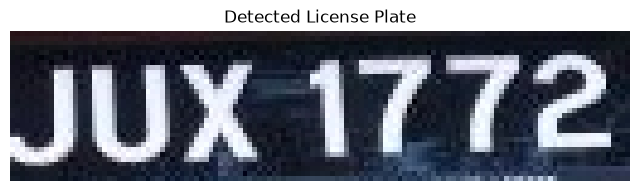

In [157]:
# =====================================================
# Test License Plate Detection
# =====================================================

# Replace with your own image
image, plate_crop, bbox = detect_license_plate(TEST_IMAGE_PATH)

if plate_crop is None:

    print("No license plate detected.")

else:

    plt.figure(figsize=(8,3))

    plt.imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))

    plt.title("Detected License Plate")

    plt.axis("off")

    plt.show()

# 8. Optical Character Recognition (OCR)

Once the license plate has been detected and cropped, the image is passed through the CRNN model for character recognition.

The cropped license plate is first preprocessed using the same pipeline employed during training. The processed image is then fed into the CRNN model, and the resulting predictions are decoded using the CTC decoding algorithm to obtain the final license plate text.

In [158]:
# =====================================================
# Recognize License Plate
# =====================================================

def recognize_plate(plate_crop):
    """
    Recognize characters using CRNN.
    """

    image = preprocess_plate(plate_crop)

    with torch.no_grad():

        output = model(image)

        text = ctc_decode(output)

    return text

## 8.1 Test OCR Recognition

This section verifies the OCR module by recognizing the characters from a detected license plate image.

The cropped license plate obtained from the previous detection step is passed into the CRNN model. The recognized license plate number is then displayed.

In [159]:
# =====================================================
# Test OCR Recognition
# =====================================================

if plate_crop is None:

    print("No license plate available for OCR.")

else:

    plate_text = recognize_plate(plate_crop)

    print("=" * 60)
    print("Recognized Plate :", plate_text)
    print("=" * 60)

Recognized Plate : JUM1772


# 9. Automatic Number Plate Recognition (ANPR) Pipeline

This section integrates the license plate detection and optical character recognition (OCR) modules into a complete Automatic Number Plate Recognition (ANPR) pipeline.

The pipeline first detects the license plate using the trained YOLOv8 model. The detected license plate is then cropped and passed to the CRNN model for character recognition. Finally, the recognized license plate number is displayed together with the detected bounding box on the original image.

This integrated pipeline demonstrates the complete workflow of the proposed ANPR system.

In [160]:
# =====================================================
# Complete ANPR Pipeline
# =====================================================

def anpr_pipeline(image_path):
    """
    Complete ANPR Pipeline

    Parameters
    ----------
    image_path : str
        Path to the input image.

    Returns
    -------
    image : numpy.ndarray
        Original image with bounding box and recognized text.

    plate_crop : numpy.ndarray
        Cropped license plate image.

    plate_text : str
        Recognized license plate.
    """

    # -----------------------------------------------
    # Detect License Plate
    # -----------------------------------------------

    image, plate_crop, bbox = detect_license_plate(image_path)

    if plate_crop is None:

        print("No license plate detected.")

        return image, None, None

    # -----------------------------------------------
    # Recognize License Plate
    # -----------------------------------------------

    plate_text = recognize_plate(plate_crop)

    # -----------------------------------------------
    # Draw Bounding Box
    # -----------------------------------------------

    x1, y1, x2, y2 = bbox

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv2.putText(
        image,
        plate_text,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    # -----------------------------------------------
    # Return Results
    # -----------------------------------------------

    return image, plate_crop, plate_text

## 9.1 Test the Complete ANPR Pipeline

This section evaluates the complete ANPR pipeline using a sample vehicle image.

The input image is processed through the license plate detection and OCR modules. The final output consists of the detected license plate location together with the recognized license plate number displayed on the original image.

Recognized Plate : JUM1772


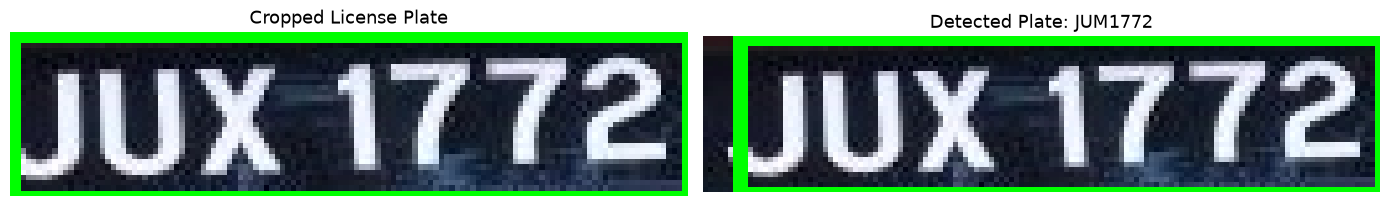

In [161]:
# =====================================================
# Test Complete ANPR Pipeline
# =====================================================



result_image, plate_crop, plate_text = anpr_pipeline(TEST_IMAGE_PATH)

print("=" * 60)
print("Recognized Plate :", plate_text)
print("=" * 60)

# =====================================================
# Display Results
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ----------------------------------------
# Cropped License Plate
# ----------------------------------------

if plate_crop is not None:

    axes[0].imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Cropped License Plate", fontsize=13)

else:

    axes[0].text(
        0.5,
        0.5,
        "No Plate Detected",
        ha="center",
        va="center",
        fontsize=12
    )

axes[0].axis("off")

# ----------------------------------------
# Final Detection Result
# ----------------------------------------

axes[1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Detected Plate: {plate_text}", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# 10. JPJ Compliance Validation

Once the license plate has been detected (`plate_crop`, `bbox`) and recognized (`plate_text`),
the final stage of the system checks whether the plate is **compliant with JPJ (Jabatan
Pengangkutan Jalan) regulations**. This is a rule-based/heuristic post-processing stage — it does
not retrain or replace the YOLOv8/CRNN models, it validates their output.

Eight checks are performed:

| Step | Name | Question |
|---|---|---|
| 10.1 | Plate Format Validation | Is the recognized plate in a valid Malaysian registration format? |
| 10.2 | Character Validation | Does an independent OCR engine agree with the CRNN prediction? |
| 10.3 | Plate Colour Validation | Is the plate colour compliant with JPJ regulations? |
| 10.4 | Font Validation | Does the character appearance resemble the standard JPJ font? |
| 10.5 | Plate Dimension Measurement | Are the plate dimensions within expected proportions? |
| 10.6 | Character Spacing Measurement | Is the spacing between characters approximately uniform? |
| 10.7 | Plate Type Classification | What type of Malaysian registration plate is it? |
| 10.8 | Compliance Decision | Combine all results into a final JPJ compliance assessment |

This section reuses `plate_crop`, `plate_text`, and `bbox` produced by the ANPR pipeline in
Section 9. If those variables aren't already in memory (e.g. you're running this section on its
own), the next cell re-runs `anpr_pipeline()` on `TEST_IMAGE` to populate them.


In [162]:
# =====================================================
# Prepare ANPR Output for JPJ Compliance Checking
# =====================================================

import re
import json as _json

print("=" * 60)
print("Preparing JPJ Compliance Checking")
print("=" * 60)

# -----------------------------------------------------
# Check whether ANPR results already exist
# -----------------------------------------------------
try:
    plate_crop
    plate_text

    print("✓ Existing ANPR results found.")

except NameError:

    print("⚠ ANPR results not found.")
    print("Running ANPR pipeline on TEST_IMAGE...\n")

    result_image, plate_crop, plate_text = anpr_pipeline(TEST_IMAGE)

# -----------------------------------------------------
# Validate ANPR output
# -----------------------------------------------------
if plate_crop is None:
    raise RuntimeError(
        "License plate detection failed.\n"
        "No license plate crop is available for JPJ compliance checking."
    )

if plate_text is None or plate_text.strip() == "":
    raise RuntimeError(
        "License plate recognition failed.\n"
        "No recognized plate text is available for JPJ compliance checking."
    )

# -----------------------------------------------------
# Display ANPR output
# -----------------------------------------------------
print("\nANPR Output")
print("-" * 60)
print(f"Recognized Plate : {plate_text}")
print(f"Plate Image Size : {plate_crop.shape}")
print("-" * 60)
print("JPJ Compliance Checking is ready.")
print("=" * 60)

Preparing JPJ Compliance Checking
✓ Existing ANPR results found.

ANPR Output
------------------------------------------------------------
Recognized Plate : JUM1772
Plate Image Size : (31, 128, 3)
------------------------------------------------------------
JPJ Compliance Checking is ready.


## 10.1 Plate Format Validation

Checks `plate_text` against known Malaysian registration plate patterns:

- **Standard private/commercial**: 1–3 letters + 1–4 digits + optional 1 trailing letter (e.g. `ABC1234`, `WXY1234D`)
- **Taxi / rental / hire ("H" series)**: letter series ending in `H` (e.g. `ABH1234`)
- **Diplomatic plates**: `<digits> <2-letter code> <digits>` e.g. `1234 CD 62`
- **Military plates**: prefix `Z` followed by digits, e.g. `Z123456`

This stage only validates *string format* — colour, font, and dimensions are handled separately below.


In [163]:
# =====================================================
# 5.1 Plate Format Validation
# =====================================================

PLATE_FORMAT_PATTERNS = {
    "Standard":    r"^[A-Z]{1,3}\d{1,4}[A-Z]?$",
    "Diplomatic":  r"^\d{1,4}[A-Z]{2}\d{1,3}$",
    "Military":    r"^Z\d{3,6}$",
    "Taxi / Hire": r"^[A-Z]{1,2}H\d{1,4}[A-Z]?$",
}


def validate_plate_format(text):
    """
    Validate the recognized license plate text against
    Malaysian registration plate formats.
    """

    # -------------------------------------------------
    # Input Validation
    # -------------------------------------------------
    if text is None or str(text).strip() == "":
        return {
            "status": False,
            "decision": "FAIL",
            "recognized_text": text,
            "cleaned_text": "",
            "plate_type": None,
            "reason": "No license plate text available."
        }

    # -------------------------------------------------
    # Text Pre-processing
    # -------------------------------------------------
    cleaned = (
        str(text)
        .strip()
        .upper()
        .replace("-", "")
        .replace(" ", "")
    )

    # -------------------------------------------------
    # Match against known Malaysian plate formats
    # -------------------------------------------------
    matched_type = None

    for plate_type, pattern in PLATE_FORMAT_PATTERNS.items():
        if re.fullmatch(pattern, cleaned):
            matched_type = plate_type
            break

    # -------------------------------------------------
    # Validation Result
    # -------------------------------------------------
    if matched_type:

        return {
            "status": True,
            "decision": "PASS",
            "recognized_text": text,
            "cleaned_text": cleaned,
            "plate_type": matched_type,
            "reason": f"Matches Malaysian {matched_type} plate format."
        }

    return {
        "status": False,
        "decision": "FAIL",
        "recognized_text": text,
        "cleaned_text": cleaned,
        "plate_type": None,
        "reason": "No valid Malaysian license plate format matched."
    }


# =====================================================
# Plate Format Validation Result
# =====================================================

format_result = validate_plate_format(plate_text)

print("=" * 60)
print("5.1 Plate Format Validation")
print("=" * 60)

print(_json.dumps(format_result, indent=4))

print("=" * 60)

5.1 Plate Format Validation
{
    "status": true,
    "decision": "PASS",
    "recognized_text": "JUM1772",
    "cleaned_text": "JUM1772",
    "plate_type": "Standard",
    "reason": "Matches Malaysian Standard plate format."
}


## 10.2 Character Validation (Independent OCR Cross-check)

Runs a second, independent OCR engine (Tesseract) over `plate_crop` and compares its reading to
the CRNN prediction (`plate_text`), character by character. Agreement increases confidence that
the CRNN reading reflects the actual plate rather than a model artifact.

> **Production note**: Tesseract is used here as a readily-available second opinion. For a
> stronger independence guarantee, replace it with a differently-trained model or a cloud OCR API.


In [164]:
# =====================================================
# 5.2 Character Validation
# =====================================================

import cv2
import re
import json
import easyocr

# =====================================================
# Initialize EasyOCR
# =====================================================

try:
    reader = easyocr.Reader(['en'], gpu=True)
    EASYOCR_AVAILABLE = True
    print("✓ EasyOCR loaded successfully.")
except Exception as e:
    EASYOCR_AVAILABLE = False
    print(f"EasyOCR unavailable: {e}")


# =====================================================
# Preprocessing
# =====================================================

def preprocess_for_ocr(plate_img):
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    _, thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return thresh


# =====================================================
# EasyOCR Reading
# =====================================================

def independent_ocr_read(plate_img):

    if not EASYOCR_AVAILABLE:
        return ""

    proc = preprocess_for_ocr(plate_img)

    results = reader.readtext(
        proc,
        detail=0,
        paragraph=False
    )

    text = "".join(results)

    # Keep only A-Z and 0-9
    text = re.sub(r"[^A-Z0-9]", "", text.upper())

    return text


# =====================================================
# Character Agreement
# =====================================================

def char_level_agreement(a, b):

    if not a or not b:
        return 0.0

    n = min(len(a), len(b))

    matches = sum(
        1
        for i in range(n)
        if a[i] == b[i]
    )

    return matches / max(len(a), len(b))


# =====================================================
# Character Validation
# =====================================================

def validate_characters(plate_img, crnn_text):

    secondary = independent_ocr_read(plate_img)

    agreement = char_level_agreement(
        crnn_text.upper(),
        secondary
    )

    exact_match = (
        crnn_text.upper() == secondary
    )

    return {
        "step": "5.2_character_validation",
        "crnn_text": crnn_text,
        "easyocr_text": secondary,
        "easyocr_available": EASYOCR_AVAILABLE,
        "char_agreement_ratio": round(agreement, 3),
        "exact_match": exact_match,
        "passes": exact_match or agreement >= 0.8
    }


# =====================================================
# Run Character Validation
# =====================================================

result_5_2 = validate_characters(
    plate_crop,
    plate_text
)

print("=" * 60)
print("5.2 Character Validation")
print("=" * 60)
print(json.dumps(result_5_2, indent=4))
print("=" * 60)

✓ EasyOCR loaded successfully.
5.2 Character Validation
{
    "step": "5.2_character_validation",
    "crnn_text": "JUM1772",
    "easyocr_text": "JUX1772",
    "easyocr_available": true,
    "char_agreement_ratio": 0.857,
    "exact_match": false,
    "passes": true
}


## 10.3 Plate Colour Validation

JPJ colour conventions for registration plates:

| Colour scheme | Vehicle category |
|---|---|
| Black text on white | Private vehicles |
| White text on black | Commercial / goods vehicles |
| Black text on yellow | Taxis |
| Red text on white | Government vehicles |
| White text on blue | Diplomatic vehicles (CD/CC) |

The background/foreground colours of `plate_crop` are sampled in HSV space (via Otsu thresholding
to separate characters from background) and classified against these reference ranges.


In [165]:
# =====================================================
# 5.3 Plate Color Validation
# =====================================================

import cv2
import json
import numpy as np

JPJ_COLOR_RANGES_HSV = {
    "white":  {"lower": (0, 0, 180),   "upper": (180, 40, 255)},
    "black":  {"lower": (0, 0, 0),     "upper": (180, 255, 60)},
    "red_1":  {"lower": (0, 80, 80),   "upper": (10, 255, 255)},
    "red_2":  {"lower": (160, 80, 80), "upper": (180, 255, 255)},
    "blue":   {"lower": (95, 80, 80),  "upper": (130, 255, 255)},
    "green":  {"lower": (35, 50, 50),  "upper": (85, 255, 255)},
    "yellow": {"lower": (20, 80, 120), "upper": (35, 255, 255)},
    "orange": {"lower": (10, 100, 100),"upper": (20, 255, 255)},
    "brown":  {"lower": (10, 60, 20),  "upper": (20, 255, 120)},
    "gray":   {"lower": (0, 0, 60),    "upper": (180, 40, 180)}
}

VALID_BACKGROUND_FOREGROUND_COMBOS = {
    ("black", "white"): "Standard Vehicle",
    ("white", "black"): "Taxi / Rental Vehicle",
    ("red", "white"): "Diplomatic / UN Vehicle",
    ("white", "black_green"): "JPJePlate EV"
}


def dominant_hsv_color(hsv_pixels):
    counts = {}
    for name, rng in JPJ_COLOR_RANGES_HSV.items():
        counts[name] = np.count_nonzero(cv2.inRange(hsv_pixels, np.array(rng["lower"]), np.array(rng["upper"])))
    counts["red"] = counts.pop("red_1") + counts.pop("red_2")
    return max(counts, key=counts.get) if max(counts.values()) > 0 else "unknown"

def validate_plate_color(plate_img):
    hsv = cv2.cvtColor(plate_img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)

    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    bg_mask = mask if np.count_nonzero(mask) > mask.size / 2 else cv2.bitwise_not(mask)
    fg_mask = cv2.bitwise_not(bg_mask)

    bg_pixels = hsv[bg_mask > 0]
    fg_pixels = hsv[fg_mask > 0]

    bg_color = dominant_hsv_color(bg_pixels.reshape(-1,1,3)) if bg_pixels.size else "unknown"
    fg_color = dominant_hsv_color(fg_pixels.reshape(-1,1,3)) if fg_pixels.size else "unknown"

    plate_type = VALID_BACKGROUND_FOREGROUND_COMBOS.get((bg_color, fg_color))

    return {
        "step": "5.3_plate_color_validation",
        "background_color": bg_color,
        "foreground_color": fg_color,
        "plate_type": plate_type,
        "is_compliant": plate_type is not None,
        "reason": "Valid Malaysian JPJ colour combination." if plate_type else "Invalid Malaysian JPJ colour combination."
    }

result_5_3 = validate_plate_color(plate_crop)

print("="*60)
print("5.3 Plate Color Validation")
print("="*60)
print(json.dumps(result_5_3, indent=4))
print("="*60)

5.3 Plate Color Validation
{
    "step": "5.3_plate_color_validation",
    "background_color": "black",
    "foreground_color": "white",
    "plate_type": "Standard Vehicle",
    "is_compliant": true,
    "reason": "Valid Malaysian JPJ colour combination."
}


## 10.4 Font Validation

Checks whether character shapes in `plate_crop` resemble the standard JPJ font, using structural
heuristics (character height/width consistency), since exact template matching would require a
reference JPJ glyph set.

> **Production note**: replace the heuristic scorer with template matching (`cv2.matchTemplate`)
> or a small CNN classifier trained on genuine-JPJ-font vs. custom/aftermarket-font character crops
> for a stronger, production-grade decision.


In [ ]:
# =====================================================
# 5.4 Font Validation (JPJ Template Matching)
# =====================================================

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json

# =====================================================
# Load JPJ Templates
# =====================================================

TEMPLATE_DIR = Path("JPJ_Font/Templates")

templates = {}

for file in TEMPLATE_DIR.glob("*.png"):

    img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    _, img = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    templates[file.stem.upper()] = img

print(f"Loaded {len(templates)} JPJ Templates.")

# =====================================================
# Character Segmentation
# =====================================================

def segment_characters(plate_img):

    gray = cv2.cvtColor(
        plate_img,
        cv2.COLOR_BGR2GRAY
    )

    _, mask = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Make characters white
    if np.count_nonzero(mask) > mask.size/2:
        mask = cv2.bitwise_not(mask)

    kernel = np.ones((2,2), np.uint8)
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    h_img, w_img = mask.shape

    boxes = []

    for c in contours:

        x,y,w,h = cv2.boundingRect(c)

        aspect = w/h

        if (

            h > h_img*0.40 and
            h < h_img*0.98 and

            w > 3 and
            w < w_img*0.35 and

            aspect > 0.10 and
            aspect < 1.20

        ):

            boxes.append((x,y,w,h))

    boxes = sorted(boxes,key=lambda b:b[0])

    chars=[]

    for x,y,w,h in boxes:

        char = mask[y:y+h,x:x+w]

        canvas=np.zeros((64,64),dtype=np.uint8)

        scale=min(54/w,54/h)

        nw=max(1,int(w*scale))
        nh=max(1,int(h*scale))

        resized=cv2.resize(
            char,
            (nw,nh),
            interpolation=cv2.INTER_AREA
        )

        sx=(64-nw)//2
        sy=(64-nh)//2

        canvas[
            sy:sy+nh,
            sx:sx+nw
        ]=resized

        chars.append(canvas)

    return chars, boxes, mask

# =====================================================
# Font Validation
# =====================================================

def validate_font(plate_img, plate_text):

    chars, boxes, mask = segment_characters(plate_img)

    if len(chars)==0:

        return {

            "step":"5.4_font_validation",

            "characters_detected":0,

            "average_similarity":0,

            "minimum_similarity":0,

            "resembles_jpj_font":False,

            "character_results":[],

            "note":"No characters segmented."

        }

    similarities=[]
    details=[]

    print("="*70)
    print("JPJ FONT VALIDATION")
    print("="*70)

    # --------------------------------------------------
    # Draw segmentation (High Resolution)
    # --------------------------------------------------

    SCALE = 4  # 3 or 4 looks good

    display = cv2.resize(
        plate_img,
        None,
        fx=SCALE,
        fy=SCALE,
        interpolation=cv2.INTER_CUBIC
    )

    for i, (x, y, w, h) in enumerate(boxes):

        x1 = x * SCALE
        y1 = y * SCALE
        x2 = (x + w) * SCALE
        y2 = (y + h) * SCALE

        # Bright pink bounding box
        cv2.rectangle(
            display,
         (x1, y1),
           (x2, y2),
            (255, 0, 255),
        1,
            cv2.LINE_AA
        )

        # Character number
        cv2.putText(
            display,
            str(i + 1),
           (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 255),
            2,
            cv2.LINE_AA
        )

    plt.figure(figsize=(14, 4), dpi=200)
    plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
    plt.title("Detected Character Segmentation")
    plt.axis("off")
    plt.show()

    # --------------------------------------------------
    # Compare each character
    # --------------------------------------------------

    n=min(len(chars),len(plate_text))

    plt.figure(figsize=(4,n*2))

    row=1

    for i in range(n):

        predicted=plate_text[i].upper()

        if predicted not in templates:
            continue

        template=templates[predicted]

        template=cv2.resize(template,(64,64))

        score=cv2.matchTemplate(

            chars[i],

            template,

            cv2.TM_CCOEFF_NORMED

        )[0][0]

        similarities.append(score)

        details.append({

            "character":predicted,

            "similarity":round(float(score),3)

        })

        plt.subplot(n,2,row)

        plt.imshow(chars[i],cmap="gray")

        plt.title(f"Detected : {predicted}")

        plt.axis("off")

        plt.subplot(n,2,row+1)

        plt.imshow(template,cmap="gray")

        plt.title(f"JPJ ({score:.3f})")

        plt.axis("off")

        row+=2

    plt.tight_layout()

    plt.show()

    if len(similarities)==0:

        avg=0
        minimum=0

    else:

        avg=float(np.mean(similarities))

        minimum=float(np.min(similarities))

    THRESHOLD=0.85

    result={

        "step":"5.4_font_validation",

        "characters_detected":len(chars),

        "average_similarity":round(avg,3),

        "minimum_similarity":round(minimum,3),

        "resembles_jpj_font":avg>=THRESHOLD,

        "threshold":THRESHOLD,

        "character_results":details,

        "note":"JPJ font template matching."

    }

    return result

# =====================================================
# Example
# =====================================================

result_5_4 = validate_font(

    plate_crop,

    plate_text

)

print(json.dumps(result_5_4,indent=4))

Loaded 36 JPJ Templates.


Loaded 36 JPJ Templates.


## 10.5 Plate Dimension Measurement

Compares `plate_crop`'s aspect ratio against official JPJ standard proportions:

- **Single-row plate**: 520 mm × 110 mm → ratio ≈ **4.73**
- **Double-row / motorcycle plate**: 250 mm × 205 mm → ratio ≈ **1.22**

A tolerance band is applied since YOLOv8 crops are rarely pixel-perfect due to camera angle and
detection box looseness.


In [168]:
JPJ_STANDARD_RATIOS = {
    "single_row": 520 / 110,  # ~4.73 (cars, most vehicles)
    "double_row": 250 / 205,  # ~1.22 (motorcycles, some rear plates)
}
RATIO_TOLERANCE = 0.20  # 20% tolerance for perspective/crop imprecision

def validate_dimensions(plate_img):
    h, w = plate_img.shape[:2]
    measured_ratio = w / h

    best_match, best_diff = None, float("inf")
    for name, ref_ratio in JPJ_STANDARD_RATIOS.items():
        diff = abs(measured_ratio - ref_ratio) / ref_ratio
        if diff < best_diff:
            best_diff, best_match = diff, name

    return {
        "step": "10.5_plate_dimension_measurement",
        "measured_width_px": w,
        "measured_height_px": h,
        "measured_aspect_ratio": round(measured_ratio, 3),
        "closest_standard": best_match,
        "closest_standard_ratio": round(JPJ_STANDARD_RATIOS[best_match], 3),
        "relative_deviation": round(best_diff, 3),
        "within_expected_proportions": best_diff <= RATIO_TOLERANCE,
    }

result_10_5 = validate_dimensions(plate_crop)
print(json.dumps(result_10_5, indent=2))


{
  "step": "10.5_plate_dimension_measurement",
  "measured_width_px": 128,
  "measured_height_px": 31,
  "measured_aspect_ratio": 4.129,
  "closest_standard": "single_row",
  "closest_standard_ratio": 4.727,
  "relative_deviation": 0.127,
  "within_expected_proportions": true
}


## 10.6 Character Spacing Measurement

Reuses the character bounding boxes from Section 10.4, measures the horizontal gap between
consecutive characters, and checks that gaps are approximately uniform (low coefficient of
variation), as required by JPJ spacing rules.


In [169]:
def measure_char_spacing(boxes):
    if len(boxes) < 2:
        return {
            "step": "10.6_character_spacing_measurement",
            "num_gaps_measured": 0,
            "gaps_px": [],
            "mean_gap_px": None,
            "gap_coefficient_of_variation": None,
            "is_spacing_uniform": None,
            "note": "Fewer than 2 characters detected -- cannot measure spacing.",
        }

    gaps = []
    for i in range(1, len(boxes)):
        prev_x, prev_y, prev_w, prev_h = boxes[i - 1]
        cur_x, cur_y, cur_w, cur_h = boxes[i]
        gaps.append(max(cur_x - (prev_x + prev_w), 0))

    mean_gap = float(np.mean(gaps))
    std_gap = float(np.std(gaps))
    cv_gap = (std_gap / mean_gap) if mean_gap > 0 else float("inf")

    UNIFORMITY_CV_THRESHOLD = 0.5  # tune against real labeled plates

    return {
        "step": "10.6_character_spacing_measurement",
        "num_gaps_measured": len(gaps),
        "gaps_px": gaps,
        "mean_gap_px": round(mean_gap, 2),
        "gap_coefficient_of_variation": round(cv_gap, 3) if cv_gap != float("inf") else None,
        "is_spacing_uniform": cv_gap <= UNIFORMITY_CV_THRESHOLD,
    }

char_boxes = segment_characters(plate_crop)
result_10_6 = measure_char_spacing(char_boxes)
print(json.dumps(result_10_6, indent=2))

# Visual sanity check of detected character boxes
vis = plate_crop.copy()
for (x, y, w, h) in char_boxes:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(8, 3))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Detected Character Boxes")
plt.axis("off")
plt.show()


ValueError: too many values to unpack (expected 4)

## 10.7 Plate Type Classification

Classifies the plate's vehicle category using the colour result (10.3) and format result (10.1)
together -- colour alone can be ambiguous (e.g. custom black-on-white plates vs. government
red-on-white), so combining both signals gives a more reliable classification.


In [ ]:
def classify_plate_type(format_result, color_result):
    color_category = color_result.get("inferred_vehicle_category")
    matched_formats = format_result.get("matched_formats", [])

    if "military" in matched_formats:
        plate_type = "Military"
    elif "diplomatic" in matched_formats or color_category == "Diplomatic vehicle":
        plate_type = "Diplomatic"
    elif "taxi_hire" in matched_formats or color_category == "Taxi":
        plate_type = "Taxi / Hire vehicle"
    elif color_category == "Government vehicle":
        plate_type = "Government"
    elif color_category == "Commercial / goods vehicle":
        plate_type = "Commercial / Goods vehicle"
    elif color_category == "Private vehicle":
        plate_type = "Private vehicle"
    else:
        plate_type = "Unclassified"

    confidence = "high" if (color_category is not None and matched_formats) else "low"

    return {
        "step": "10.7_plate_type_classification",
        "inferred_plate_type": plate_type,
        "based_on_color_category": color_category,
        "based_on_matched_formats": matched_formats,
        "classification_confidence": confidence,
    }

result_10_7 = classify_plate_type(result_10_1, result_10_3)
print(json.dumps(result_10_7, indent=2))


NameError: name 'result_10_1' is not defined

## 10.8 Compliance Decision

Combines every check above into one final JPJ compliance verdict. Format and colour are treated
as **critical checks** that must both pass for the plate to be considered compliant at all; the
remaining checks feed into an overall confidence score.


In [ ]:
def final_compliance_decision(r1, r2, r3, r4, r5, r6, r7):
    checks = {
        "format_valid":       r1["is_valid_format"],
        "character_verified": r2["passes"],
        "color_compliant":    r3["is_compliant_combo"],
        "font_matches_jpj":   bool(r4["resembles_jpj_font"]),
        "dimensions_valid":   r5["within_expected_proportions"],
        "spacing_uniform":    bool(r6["is_spacing_uniform"]) if r6["is_spacing_uniform"] is not None else False,
    }

    CRITICAL_CHECKS = ["format_valid", "color_compliant"]
    critical_pass = all(checks[c] for c in CRITICAL_CHECKS)

    passed_count = sum(1 for v in checks.values() if v)
    total_count = len(checks)
    confidence_score = round(passed_count / total_count, 3)

    if critical_pass and confidence_score >= 0.8:
        verdict = "COMPLIANT"
    elif critical_pass and confidence_score >= 0.5:
        verdict = "LIKELY COMPLIANT -- manual review recommended"
    else:
        verdict = "NON-COMPLIANT"

    return {
        "step": "10.8_compliance_decision",
        "individual_checks": checks,
        "critical_checks_passed": critical_pass,
        "checks_passed": f"{passed_count}/{total_count}",
        "confidence_score": confidence_score,
        "plate_type": r7["inferred_plate_type"],
        "final_verdict": verdict,
    }

result_10_8 = final_compliance_decision(
    result_10_1, result_10_2, result_10_3, result_10_4, result_10_5, result_10_6, result_10_7
)
print(json.dumps(result_10_8, indent=2))


NameError: name 'result_10_7' is not defined

## 10.9 Full Compliance Report Summary

In [ ]:
compliance_report = {
    "plate_text": plate_text,
    "10.1_format": result_10_1,
    "10.2_character": result_10_2,
    "10.3_color": result_10_3,
    "10.4_font": result_10_4,
    "10.5_dimensions": result_10_5,
    "10.6_spacing": result_10_6,
    "10.7_type": result_10_7,
    "10.8_final_decision": result_10_8,
}

print("=" * 60)
print(f"PLATE      : {compliance_report['plate_text']}")
print(f"VERDICT    : {result_10_8['final_verdict']}")
print(f"CONFIDENCE : {result_10_8['confidence_score']}")
print(f"PLATE TYPE : {result_10_7['inferred_plate_type']}")
print("=" * 60)

# Uncomment to save the full report to disk:
# with open("jpj_compliance_report.json", "w") as f:
#     json.dump(compliance_report, f, indent=2)


NameError: name 'result_10_7' is not defined

### Notes for productionizing

- **10.2 (Character Validation)**: swap Tesseract for a genuinely independent second model --
  ideally a different architecture/training data from the CRNN -- for a stronger cross-check.
- **10.4 (Font Validation)**: build a reference set of genuine JPJ character crops and use
  template matching (`cv2.matchTemplate`) or a lightweight CNN classifier instead of the
  aspect-ratio heuristic.
- **10.5 (Dimension Measurement)**: for real-world mm measurements (not just aspect ratio),
  calibrate pixels-per-mm using a known reference object in frame, or camera intrinsics.
- **Thresholds** (`RATIO_TOLERANCE`, `UNIFORMITY_CV_THRESHOLD`, `MAX_AR_STD`, etc.) should be
  tuned against a labeled dataset of real compliant vs. non-compliant Malaysian plates.


# 11. Conclusion

This notebook demonstrates the complete implementation of the proposed Automatic Number Plate Recognition (ANPR) system by integrating the YOLOv8 object detection model with the Convolutional Recurrent Neural Network (CRNN) optical character recognition model.

The developed pipeline successfully performs the following tasks:

- Validates the recognized plate against JPJ compliance rules (format, colour, font, dimensions, spacing, and plate type).
- Detects the license plate from a vehicle image using the trained YOLOv8 model.
- Extracts the detected license plate region.
- Preprocesses the cropped license plate image for OCR.
- Recognizes the license plate characters using the trained CRNN model.
- Decodes the predicted character sequence using Connectionist Temporal Classification (CTC) decoding.
- Displays the detected license plate together with the recognized license plate number.

The integration of these components demonstrates the effectiveness of the proposed ANPR system for automatic license plate detection and recognition. This notebook represents the complete inference workflow of the developed system and validates the implementation presented in this Final Year Project.

Input Vehicle Image
        │
        ▼
YOLOv8 Detection
        │
        ▼
Crop License Plate
        │
        ▼
Image Preprocessing
        │
        ▼
CRNN OCR
        │
        ▼
CTC Decoding
        │
        ▼
Recognized License Plate
        │
        ▼
JPJ Compliance Validation
        │
        ▼
Final Compliance Decision
